# บทที่ 2 - ชุดข้อมูลมหัศจรรย์และถิ่นที่อยู่

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai-builders/curriculum/blob/main/notebooks/02_fantastic_datasets_2026_th.ipynb)

## สิ่งที่เราจะเรียนในบทนี้

ยินดีต้อนรับสู่ **ชุดข้อมูลมหัศจรรย์และถิ่นที่อยู่** บทเรียนที่ 2 ของหลักสูตร AI Builders ฉบับปี 2026

ในบทที่ 1 เราเรียนรู้ว่าระบบ AI *คืออะไร* และ *เรียนรู้อย่างไร* (training loop) แต่ทุก training loop ต้องการเชื้อเพลิงนั่นคือ **ข้อมูล** ทั้งนี้ คุณภาพและปริมาณของข้อมูลมักสำคัญกว่าโมเดลที่คุณเลือก

ใน notebook นี้เราจะครอบคลุม:

1. **Data-Centric AI**; ทำไมคุณภาพข้อมูลถึงสำคัญกว่าขนาดโมเดล พร้อมหลักฐานจริง
2. **แหล่งค้นหาชุดข้อมูล**; open data, task taxonomy, และ licensing
3. **สร้างชุดข้อมูลรูปภาพจากการค้นหา**; ค้นหารูปภาพ → ดาวน์โหลด → ตรวจสอบ → ทำความสะอาด
4. **โหลดและสำรวจข้อมูลที่มีอยู่**; HuggingFace Datasets + EDA ด้วย pandas
5. **Web scraping**; เก็บข้อมูลจากเว็บไซต์ทั้ง static และ dynamic
6. **สร้างข้อมูลสังเคราะห์**; text (DSPy + Qwen3-0.6B), images (Tiny Stable Diffusion), และ tabular (อ้างอิง [AdaRec](https://github.com/amazon-science/AdaRec))
7. **Data quality checklist**; รายการตรวจสอบคุณภาพข้อมูลที่สอดคล้องกับเกณฑ์การให้คะแนน
8. **แผนข้อมูลของคุณ**; แบบฟอร์มเตรียมพร้อมสำหรับโครงงาน

เมื่อจบบทเรียนนี้ คุณจะมีประสบการณ์ตรงกับทุกวิธีหลักในการหาข้อมูลสำหรับเทรนโมเดล และมีวิจารณญาณในการเลือกวิธีที่เหมาะกับโครงงานของคุณ

## ลงโปรแกรมสำหรับบทเรียน

เซลล์ด้านล่างจะตรวจจับว่าคุณกำลังรันบน **Google Colab** หรือ **เครื่องตัวเอง**

- **Colab**: dependencies จะถูกติดตั้งอัตโนมัติผ่าน `pip`
- **เครื่องตัวเอง** (เช่น MacBook Pro ที่ใช้ Apple Silicon): ตั้งค่า environment ด้วย `uv`:

```bash
uv pip install dspy torch transformers bitsandbytes accelerate fastai \
    matplotlib datasets icrawler beautifulsoup4 requests \
    pandas diffusers google-colab-selenium
```

หรือถ้ามี `requirements.txt`:

```bash
uv pip install -r requirements.txt
```

In [1]:
import os, subprocess, sys

# --- Detect environment ---
IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

LESSON_2_DEPS = [
    "dspy", "torch", "transformers", "bitsandbytes", "accelerate",
    "fastai", "matplotlib", "datasets",
    "icrawler", "beautifulsoup4", "requests",
    "pandas", "diffusers",
]

if IN_COLAB:
    print("Running on Google Colab — installing dependencies...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         *LESSON_2_DEPS, "google-colab-selenium"]
    )
    print("Done!")
else:
    print("Running locally. Make sure you've set up your environment:")
    print(f"  uv pip install {' '.join(LESSON_2_DEPS)}")
    print("Or: uv pip install -r requirements.txt")

# --- Device setup ---
import torch

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Silicon MPS")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print(f"\nDevice: {DEVICE}")

Running locally. Make sure you've set up your environment:
  uv pip install dspy torch transformers bitsandbytes accelerate fastai matplotlib datasets icrawler beautifulsoup4 requests pandas diffusers
Or: uv pip install -r requirements.txt
Using Apple Silicon MPS

Device: mps


## 1. Data-Centric AI — ทำไมคุณภาพข้อมูลถึงสำคัญกว่าขนาดโมเดล

ในบทที่ 1 เราเห็นสามแนวทางในการสร้างระบบ AI: rule-based, ML, และ LLM systems ทุกแนวทางมีสิ่งหนึ่งที่เหมือนกัน: **ระบบจะดีได้เท่ากับข้อมูลที่มันเรียนรู้เท่านั้น**

แนวคิด [Data-Centric AI](https://datacentricai.org/) ที่ Andrew Ng ทำให้เป็นที่รู้จัก เสนอว่าแทนที่จะปรับแต่งสถาปัตยกรรมโมเดลไม่รู้จบ เราควรใช้เวลาปรับปรุงข้อมูลให้มากขึ้น ทั้งปริมาณ คุณภาพ และความหลากหลาย ต่อไปนี้คือสามผลงานวิจัยสำคัญที่พิสูจน์ประเด็นนี้

### LIMA: น้อยแต่มาก สำหรับ Alignment

[Zhou et al. (2023)](https://arxiv.org/abs/2305.11206) ปรับแต่ง LLaMA-65B ด้วยตัวอย่างที่คัดสรรอย่างดีเพียง **1,000 ตัวอย่าง** ด้วยวิธี self-supervision พื้นฐานและได้โมเดลที่ผลลัพธ์เทียบเท่ากับ GPT-4 และโมเดลที่เทรนด้วย RLHF บนข้อมูลมากกว่าหลายเท่า

ข้อสังเกตสำคัญ: ตัวอย่าง 1,000 ตัวอย่างนั้นถูก *คัดเลือกและทำความสะอาดอย่างพิถีพิถัน* โดยผู้เขียน คุณภาพของข้อมูลเหนือกว่าปริมาณ

| การเปรียบเทียบ | LIMA ถูกเลือกว่าดีกว่าหรือเทียบเท่า |
|---|---|
| LIMA (1,000 ตัวอย่าง) vs. DaVinci-003 (เทรนด้วย RLHF) | 65% |
| LIMA (1,000 ตัวอย่าง) vs. Bard | 58% |
| LIMA (1,000 ตัวอย่าง) vs. GPT-4 | 43% |

โมเดลที่ fine-tune ด้วยตัวอย่างที่คัดสรรเพียง 1,000 ตัวอย่าง ถูกเลือกเหนือ DaVinci-003 เกือบสองในสามของกรณี และยืนหยัดได้ดีเมื่อเทียบกับ GPT-4 ในเกือบครึ่งหนึ่งของการเปรียบเทียบ

### Chinchilla และ Llama 3: ข้อมูลมากกว่า > โมเดลใหญ่กว่า

[Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556) — paper "Chinchilla" — แสดงให้เห็นว่า large language models ส่วนใหญ่ถูก *เทรนน้อยเกินไป* ภายใต้งบประมาณการคำนวณที่กำหนด การเทรนโมเดลเล็กกว่าด้วยข้อมูลมากกว่าให้ผลลัพธ์ดีกว่าการเทรนโมเดลใหญ่กว่าด้วยข้อมูลน้อยกว่า โดยกฎบอกว่า 1 parameter ต้องการข้อมูลประมาณ 20 tokens

งานวิจัยนี้ประมาณ scaling law สำหรับ loss ของ language model ด้วยสมการ:

$$L(N, D) = E + \frac{A}{N^\alpha} + \frac{B}{D^\beta}$$

โดยที่ $N$ = จำนวน parameters, $D$ = จำนวน training tokens, และ $E, A, B, \alpha, \beta$ เป็นค่าคงที่ที่เทรนมาจากข้อมูล

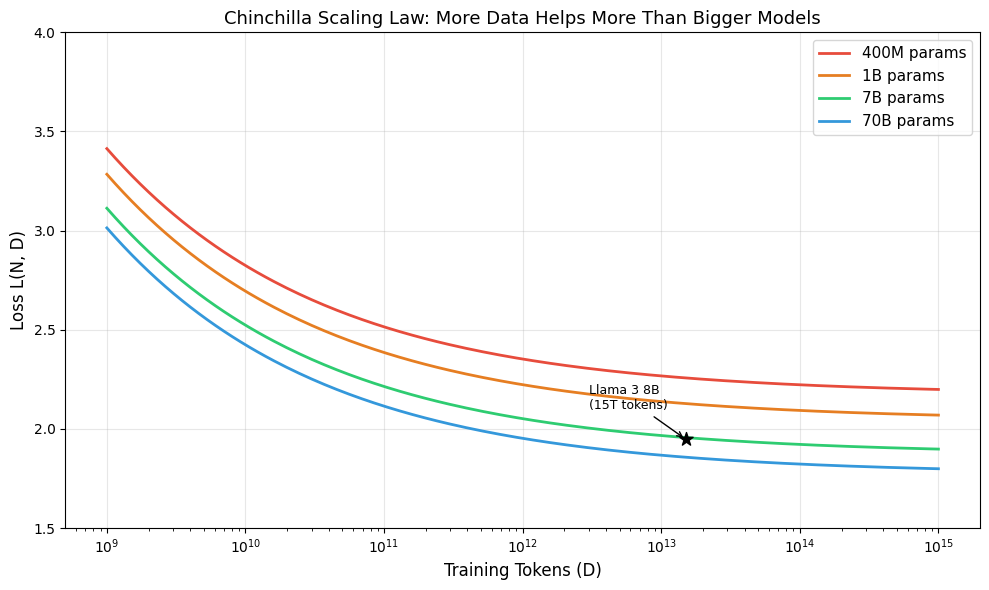

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Chinchilla scaling law: L(N, D) = E + A/N^alpha + B/D^beta
# Fitted constants from Hoffmann et al. (2022), Approach 3
E, A, B = 1.69, 406.4, 410.7
alpha, beta = 0.34, 0.28

def chinchilla_loss(N, D):
    return E + A / N**alpha + B / D**beta

# Training tokens (x-axis): 1B to 10T
D = np.logspace(9, 15, 200)

# Different model sizes
model_sizes = {
    '400M':  400e6,
    '1B':    1e9,
    '7B':    7e9,
    '70B':   70e9,
}

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))

for (label, N), color in zip(model_sizes.items(), colors):
    loss = chinchilla_loss(N, D)
    ax.plot(D, loss, label=f'{label} params', color=color, linewidth=2)

# Mark where Llama 3 8B sits (8B params, 15T tokens)
llama3_loss = chinchilla_loss(8e9, 15e12)
ax.scatter([15e12], [llama3_loss], color='black', s=100, zorder=5, marker='*')
ax.annotate('Llama 3 8B\n(15T tokens)', xy=(15e12, llama3_loss),
            xytext=(3e12, llama3_loss + 0.15), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xscale('log')
ax.set_xlabel('Training Tokens (D)', fontsize=12)
ax.set_ylabel('Loss L(N, D)', fontsize=12)
ax.set_title('Chinchilla Scaling Law: More Data Helps More Than Bigger Models',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(1.5, 4.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

เส้นโค้งแต่ละเส้นแสดงว่า loss ลดลงอย่างไรเมื่อป้อนข้อมูลมากขึ้นให้โมเดลแต่ละขนาด สังเกตว่า:

1. **จุดที่เส้นโค้งเริ่มแบนราบ**; ถึงจุดหนึ่ง การเพิ่มข้อมูลให้โมเดลเล็กจะไม่ช่วยอีกแล้วเพราะ โมเดลเล็กเกินไปที่จะซึมซับข้อมูลเพิ่ม
2. **โมเดลใหญ่ต้องการข้อมูลมากกว่า**; แม้เส้นโค้ง 70B ยังคงลดลงในจุดที่เส้นโค้ง 400M แบนราบไปแล้ว แต่ถ้าเทรนโมเดล 70B ด้วย token เพียง 1B มันจะทำงาน *แย่กว่า* โมเดล 1B ที่เทรนด้วย 100B tokens

ข้อสรุปจาก Chinchilla: **สำหรับงบประมาณการคำนวณที่กำหนด มีจุดสมดุลที่เหมาะสมระหว่างขนาดโมเดลและข้อมูล** โมเดลส่วนใหญ่ก่อน Chinchilla ใหญ่เกินไปเมื่อเทียบกับข้อมูลที่มี (undertrained); Llama 3 ของ Meta (ทำเครื่องหมาย ★) เป็นโมเดลใหญ่แรกที่ใช้ข้อมูลมากกว่าที่กฎบอกอย่างใหญ่หลวง คือเทรนโมเดล 8B ด้วย 15T tokens (1:200!!)

### Phi-1: Textbooks Are All You Need

[Gunasekar et al. (2023)](https://arxiv.org/abs/2306.11644) เทรน **Phi-1** โมเดลขนาด 1.3B parameters ด้วยข้อมูลสังเคราะห์คุณภาพ "ระดับตำราเรียน" ที่สร้างโดย GPT-3.5 แม้จะเล็กมากตามมาตรฐาน LLM แต่ Phi-1 เอาชนะโมเดลที่ใหญ่กว่า 10 เท่าใน coding benchmarks:

| โมเดล | Parameters | Training Data | HumanEval (pass@1) | MBPP (pass@1) |
|---|---|---|---|---|
| StarCoder | 15.5B | 1T tokens (The Stack) | 33.6% | 52.7% |
| GPT-3.5 | 175B | ไม่เปิดเผย (มหาศาล) | 48.1% | — |
| **phi-1** | **1.3B** | **7B tokens (คุณภาพระดับตำราเรียน)** | **50.6%** | **55.5%** |
| GPT-4 | ไม่เปิดเผย (มหาศาล) | ไม่เปิดเผย (มหาศาล) | 67.0% | — |

phi-1 เอาชนะ GPT-3.5 (ซึ่งใหญ่กว่า 135 เท่า) และ StarCoder (ซึ่งใหญ่กว่า 12 เท่าและเทรนด้วยข้อมูลมากกว่า 140 เท่า) ความลับไม่ใช่ขนาด แต่คือ **คุณภาพข้อมูล** ข้อมูลสังเคราะห์คุณภาพระดับตำราเรียน 7B tokens มีค่ามากกว่า 1T tokens ของโค้ดดิบจากอินเทอร์เน็ต

สิ่งนี้เชื่อมโยงโดยตรงกับสิ่งที่เราจะทำในบทเรียนนี้: **สร้างข้อมูลสังเคราะห์** ด้วย LLMs

```
ข้อสรุป Data-Centric:

  ข้อมูลดีกว่า    →  โมเดลดีกว่า   (จริงเสมอ)
  โมเดลใหญ่กว่า →  ผลลัพธ์ดีกว่า   (เฉพาะเมื่อมีข้อมูลดีเพียงพอ)
```

### ระดับความพยายามในการจัดหาข้อมูล

สำหรับโครงงาน AI Builders ข้อมูลที่คุณใช้ต้องมี **ความพยายามที่ไม่ธรรมดา** คุณไม่สามารถแค่ดาวน์โหลดชุดข้อมูลสะอาดจาก Kaggle มาทำความสะอาดเล็กน้อย-กดเทรนโมเดลแล้วจบ 

นี่คือวิธีที่เราคิดเกี่ยวกับระดับความพยายาม:

```
ระดับ 1 (น้อย)      → ดาวน์โหลดชุดข้อมูลสะอาดมาปรับเล็กน้อย                  ← ไม่เพียงพอ
ระดับ 2 (ปานกลาง)   → รวมข้อมูลจากหลายแหล่ง, ทำความสะอาดและแปลงข้อมูล      ← พอผ่านได้
ระดับ 3 (มาก)       → Scrape/เก็บข้อมูลดิบ, ทำ label เอง                 ← ดี
ระดับ 4 (สูง)       → สร้าง + คัดสรรข้อมูลสังเคราะห์ หรือสร้าง                ← ยอดเยี่ยม
                    ชุดข้อมูลใหม่ตั้งแต่ต้น
```

ส่วนที่ยากของ ML ในโลกจริงแทบไม่เคยเป็นเรื่องโมเดล แต่เป็นเรื่องการหาข้อมูลที่ดี ถ้าคุณข้ามขั้นตอนนี้ คุณก็ข้ามทักษะที่สำคัญที่สุด เนื้อหาที่เหลือของบทเรียนนี้จะสอนทักษะสำหรับระดับ 2–4

## 2. แหล่งค้นหาชุดข้อมูล

ก่อนจะสร้างอะไร คุณต้องรู้ว่าจะหาข้อมูลจากไหน ภูมิทัศน์ของ open datasets ปัจจุบันได้ถูกรวมศูนย์มากขึ้น แพลตฟอร์มไม่กี่แห่งครอบคลุมแหล่งข้อมูลที่คุณต้องการแทบทั้งหมด

### แหล่งข้อมูลเปิด

**ทั่วไป**
- [HuggingFace Datasets](https://huggingface.co/datasets) — ศูนย์กลางหลักสำหรับทุก modality: text, images, audio, tabular, multimodal มีชุดข้อมูลมากกว่า 200,000 ชุด พร้อมการโหลดมาตรฐานผ่าน `load_dataset()`
- [Kaggle Datasets](https://www.kaggle.com/datasets) — ชุมชนใหญ่ มีชุดข้อมูลจากการแข่งขันพร้อม notebooks แสดงวิธีใช้
- [Google Dataset Search](https://datasetsearch.research.google.com/) — search engine สำหรับชุดข้อมูลโดยเฉพาะ
- [Papers with Code](https://paperswithcode.com/datasets) — ชุดข้อมูลที่เชื่อมโยงกับงานวิจัยและ benchmarks

**รูปภาพ**
- [Open Images Dataset](https://storage.googleapis.com/openimages/web/index.html) — 9 ล้านรูปพร้อม labels สำหรับ classification, detection, segmentation
- [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html) — benchmarks คลาสสิก (CIFAR, ImageNet, MNIST ฯลฯ) โหลดได้ในบรรทัดเดียว

**ข้อความและเสียง**
- [HuggingFace Datasets](https://huggingface.co/datasets) — ชุดข้อมูล NLP ส่วนใหญ่อยู่ที่นี่แล้ว
- [Common Crawl](https://commoncrawl.org/) — ข้อความดิบจากเว็บขนาด petabytes แหล่งข้อมูลเบื้องหลังการเทรน LLM ส่วนใหญ่

**ข้อมูลตาราง**
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/) — คอลเลกชันคลาสสิกของชุดข้อมูล tabular ML
- [OpenML](https://www.openml.org/) — ชุดข้อมูลตารางหลายพันชุดพร้อม metadata และ benchmarks มาตรฐาน

### ชื่อ Task สำหรับค้นหาชุดข้อมูล

เคล็ดลับ: ค้นหา `"[ชื่อ task] dataset"` ใน search engine หรือบน HuggingFace ต่อไปนี้คือชื่อ task หลักๆ แบ่งตาม modality:

**รูปภาพ**
- Image classification — จำแนกรูปภาพเป็นประเภท
- Object detection — ระบุตำแหน่งและติด label วัตถุในรูปภาพ
- Image segmentation — จำแนกแต่ละ pixel
- Image captioning — สร้างคำบรรยายรูปภาพ
- Visual question answering (VQA) — ตอบคำถามเกี่ยวกับรูปภาพ
- Image generation — สร้างรูปภาพจาก text หรือ input อื่น
- Depth estimation — ทำนายระยะห่างจากกล้องสำหรับแต่ละ pixel
- Pose estimation - ทำนายจุดต่างๆของร่างกาย-ตามความเคลื่อนไหว

**ข้อความ**
- Text classification — จำแนกข้อความ
- Named entity recognition (NER) — ระบุ entities ในข้อความ
- Question answering — ตอบคำถามจากบริบท
- Machine translation — แปลภาษา
- Summarization — สรุปข้อความยาว
- Text generation — สร้างข้อความจาก prompts
- Retrieval / semantic search — ค้นหาเอกสารที่เกี่ยวข้อง

**เสียง**
- Automatic speech recognition (ASR) — ถอดเสียงเป็นข้อความ
- Text-to-speech (TTS) — สร้างเสียงจากข้อความ
- Speaker recognition — ระบุผู้พูด
- Audio classification — จำแนกเสียง

**ข้อมูลตาราง**
- Classification — ทำนายประเภทจาก features
- Regression — ทำนายค่าต่อเนื่อง
- Time series forecasting — ทำนายค่าในอนาคต
- Recommendation — แนะนำสิ่งของให้ผู้ใช้
- Anomaly detection — ค้นหารูปแบบที่ผิดปกติ
- Clustering - จับกลุ่มตัวอย่างเข้าด้วยกัน

**Multimodal และ Agentic**
- Visual grounding — เชื่อมโยงวลีในข้อความกับบริเวณในรูปภาพ
- Document understanding — ดึงข้อมูลโครงสร้างจาก PDFs/แบบฟอร์ม
- Tool use / function calling — เทรนโมเดลให้ใช้ APIs และเครื่องมือ
- Instruction following — ประเมินว่าโมเดลทำตามคำสั่งซับซ้อนได้ดีแค่ไหน

### Licensing — รู้ก่อนใช้

ข้อมูลเปิดถูกแบ่งปันภายใต้ลิขสิทธิ์ (license) ที่กำหนดว่าคุณทำอะไรได้และไม่ได้ ตระกูลที่พบบ่อยที่สุดคือ [Creative Commons](https://creativecommons.org/):

| รหัส | ความหมาย |
|---|---|
| `CC` | Creative Commons |
| `BY` (Attribution) | ใช้ คัดลอก ดัดแปลงได้ — แต่ต้องให้เครดิตผู้สร้าง |
| `SA` (ShareAlike) | งานดัดแปลงต้องใช้ license เดียวกัน |
| `NC` (NonCommercial) | ห้ามใช้เพื่อการค้า |
| `ND` (NoDerivatives) | ห้ามดัดแปลง |

สำหรับโครงงานของคุณ เราแนะนำให้แชร์ผลงานเป็น **CC-BY-SA** — เพื่อให้ชุมชนนำไปต่อยอดได้ เหมือนที่คุณนำงานของชุมชนมาต่อยอด

**หมายเหตุเรื่องข้อมูลที่สร้างโดย LLM**: ถ้าคุณใช้ LLM สร้างข้อมูลสำหรับเทรน ให้ตรวจสอบ terms of service ของโมเดล ผู้ให้บริการบางรายจำกัดการใช้ output เพื่อเทรนโมเดลคู่แข่ง โมเดล open-weight (Llama, Qwen, Mistral) โดยทั่วไปมี license ที่อนุญาตมากกว่าสำหรับเนื้อหาที่สร้างขึ้น

คุณสามารถเลือก license ได้ที่ [creativecommons.org/choose](https://creativecommons.org/choose/)

## 3. สร้างชุดข้อมูลรูปภาพจากการค้นหา

บางครั้งคุณต้องการชุดข้อมูลรูปภาพที่ยังไม่มีอยู่ วิธีที่เร็วในการเริ่มต้นคือค้นหารูปภาพออนไลน์ ดาวน์โหลด แล้วทำความสะอาดรูปที่เสีย

เทคนิคนี้ถูกทำให้เป็นที่นิยมโดย [fastai](https://course.fast.ai/) เราใช้ [icrawler](https://github.com/hellock/icrawler) กับ backend **Bing** เพราะจัดการ rate limiting ภายในและไม่ต้องใช้ API key

มาสร้างชุดข้อมูลจำแนกรูปภาพเล็กๆ **ชิวาวา vs. บลูเบอร์รี่มัฟฟิน** กัน

In [4]:
from pathlib import Path
from icrawler.builtin import BingImageCrawler
from fastai.vision.utils import verify_images
from fastai.data.transforms import get_image_files

# Where to save images
path = Path('images_lesson2')

# Short folder names (used as class labels) mapped to search queries
searches = {'dog': 'chihuahua', 'muffin': 'blueberry muffin'}
MAX_N = 50

for folder_name, query in searches.items():
    dest = path / folder_name
    print(f'Downloading "{query}" -> {dest}/')
    crawler = BingImageCrawler(
        storage={'root_dir': str(dest)},
        log_level=20,  # INFO
    )
    crawler.crawl(keyword=query, max_num=MAX_N)
    print()

2026-04-02 22:55:53,075 - INFO - icrawler.crawler - start crawling...
2026-04-02 22:55:53,075 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-02 22:55:53,076 - INFO - feeder - thread feeder-001 exit
2026-04-02 22:55:53,076 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-02 22:55:53,077 - INFO - icrawler.crawler - starting 1 downloader threads...


2026-04-02 22:55:53,350 - INFO - parser - parsing result page https://www.bing.com/images/async?q=chihuahua&first=0
2026-04-02 22:55:54,283 - INFO - downloader - image #1	https://dogacademy.org/blog/wp-content/uploads/2023/10/24.jpg
2026-04-02 22:55:54,448 - INFO - downloader - image #2	https://dogacademy.org/blog/wp-content/uploads/2023/10/3.jpg
2026-04-02 22:55:54,627 - ERROR - downloader - Response status code 403, file https://dogsbestlife.com/wp-content/uploads/2019/04/chihuahua-apple-head.jpg
2026-04-02 22:55:55,011 - INFO - downloader - image #3	https://topdogtips.com/wp-content/uploads/Types-of-Chihuahua_-Apple-Shaped-Chihuahua-588x420.jpg
2026-04-02 22:55:55,115 - INFO - downloader - image #4	https://www.nature-and-garden.com/wp-content/uploads/sites/4/2023/07/chiwawa-chihuahua-size-1024x767.jpg
2026-04-02 22:55:55,299 - INFO - downloader - image #5	https://a-z-animals.com/media/2021/06/Apple-Head-Chihuahua-puppies.jpg
2026-04-02 22:55:55,521 - INFO - downloader - image #6	htt

2026-04-02 22:56:19,465 - INFO - parser - parsing result page https://www.bing.com/images/async?q=blueberry muffin&first=0
2026-04-02 22:56:19,786 - INFO - downloader - image #1	https://www.tasteofhome.com/wp-content/uploads/2025/03/Easy-Banana-Blueberry-Muffins_EXPS_TOHD25_278828_ChristineMa_10.jpg
2026-04-02 22:56:21,244 - INFO - downloader - image #2	https://newengland.com/wp-content/uploads/2024/06/very-blueberry-muffins-recipe.jpg
2026-04-02 22:56:21,418 - INFO - downloader - image #3	https://practicallyhomemade.com/wp-content/uploads/2024/08/blueberry-cake-muffins-hero2.jpg
2026-04-02 22:56:23,548 - INFO - downloader - image #4	https://justbaked.uk/wp-content/uploads/2023/07/JB-48043-scaled.jpg
2026-04-02 22:56:24,574 - INFO - downloader - image #5	https://gloriajeansksa.com/wp-content/uploads/2025/07/blueberry-muffin-100-1.jpg
2026-04-02 22:56:24,705 - INFO - downloader - image #6	https://www.southernkissed.com/wp-content/uploads/2023/05/Blueberry-Muffins.jpg
2026-04-02 22:56:26

In [5]:
# Check what we got
fns = get_image_files(path)
print(f'Total images downloaded: {len(fns)}')

# Verify — some downloads will be corrupted
failed = verify_images(fns)
print(f'Failed/corrupted images: {len(failed)}')

# Remove the bad ones
failed.map(Path.unlink)

# Final count
fns = get_image_files(path)
print(f'Clean images remaining: {len(fns)}')

Total images downloaded: 93


Failed/corrupted images: 0
Clean images remaining: 93


เรียบร้อย — ตอนนี้คุณมีชุดข้อมูลรูปภาพที่ติด label แล้ว สร้างจากศูนย์ด้วย search query และรูปภาพจากเว็บ

ทีนี้มาดูกันว่าส่วน *การเทรนโมเดล* ง่ายแค่ไหน — และทำไมนั่นถึงเป็นปัญหา

### การเทรนโมเดลคือส่วนที่ง่าย

ด้วย fastai การเทรน image classifier บนชุดข้อมูลของเราใช้โค้ดแค่ประมาณ 5 บรรทัดและเวลาคำนวณไม่ถึงนาที ดูนี่:

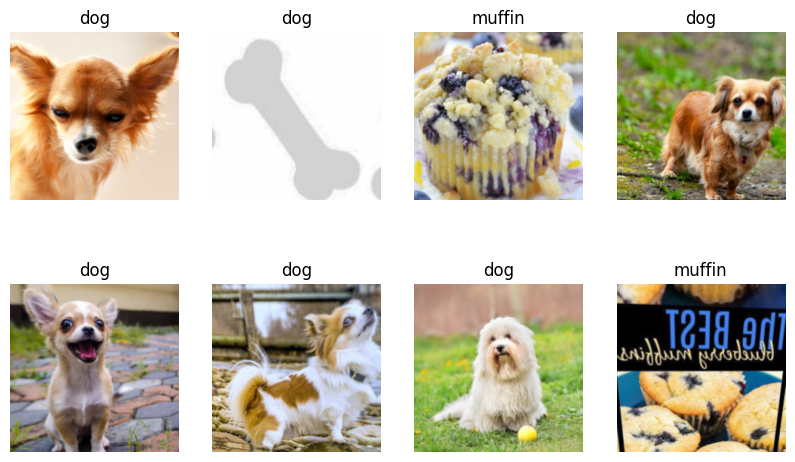

In [6]:
from fastai.vision.all import *

# Build a DataLoaders object from our folder structure
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,       # 20% for validation
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    seed=42,
)

# Show a batch to see what the model will train on
dls.show_batch(max_n=8, figsize=(10, 6))

In [7]:
# Fine-tune a pretrained ResNet34 — this is the entire training step
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,1.073902,1.172650,0.555556,00:06


epoch,train_loss,valid_loss,accuracy,time
0,0.988590,0.467064,0.833333,00:02
1,0.868294,0.017917,1.000000,00:01
2,0.643808,0.003234,1.000000,00:01


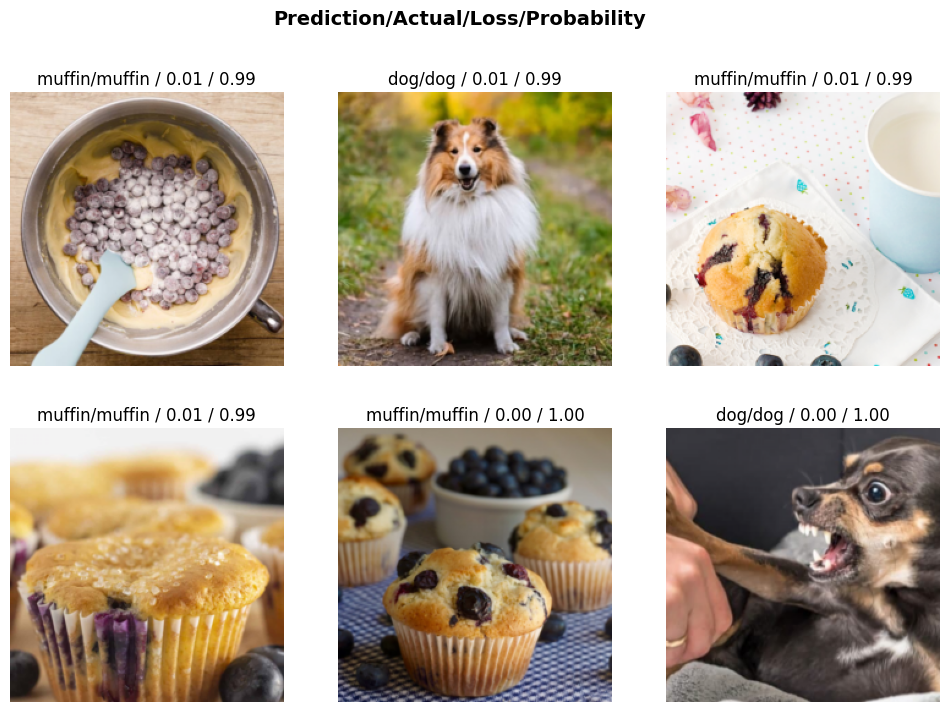

In [8]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(6, figsize=(12, 8))

### โมเดลง่าย ข้อมูลต่างหากคือความท้าทายที่แท้จริง

ด้วยเวลาแค่ไม่กี่วินาที ตอนนี้คุณมี classifier ชิวาวา-vs-มัฟฟิน แล้ว ยินดีด้วย?

ลองดู top losses ด้านบน — รูปภาพที่โมเดลสับสนมากที่สุด คุณน่าจะเห็นปัญหาหลายประเภท:

1. **รูปภาพที่ไม่เกี่ยวข้อง**; ไม่ใช่ทุกผลการค้นหาจะเป็นไปตามที่คุณขอ คุณจะพบโลโก้ มีม ภาพหน้าจอของบทความ หรือรูปที่ไม่เกี่ยวข้องเลยปนอยู่ในชุดข้อมูล โมเดลไม่มีทางรู้ว่าสิ่งเหล่านี้ไม่ควรอยู่

2. **ถูกประเภทแต่ผิดแบบ** — โฟลเดอร์ชิวาวาอาจมีชิวาวาในท่าทางต่างๆ: ยืนในสวน ใส่เสื้อกันหนาว นั่งบนโซฟา แต่ประเด็นของ task นี้คือจำแนกรูปที่ชิวาวาที่ *ดูเหมือนมัฟฟิน* — รูปถ่ายใบหน้าระยะใกล้ที่มีลักษณะกลม ชิวาวาเต็มตัววิ่งบนหญ้าเป็น label ที่ถูกต้องทางเทคนิค แต่ไม่ช่วยให้โมเดลเรียนรู้ขอบเขตการแบ่งรูปที่เราสนใจจริง ๆ

3. **กรณีที่คลุมเครือจริงๆ** — บางรูปยากจริงๆ รูปถ่ายใบหน้าชิวาวาระยะใกล้ *ดูเหมือน* มัฟฟินจริงๆ กรณีเหล่านี้คือสิ่งที่เรา *อยากให้* โมเดลเรียนรู้ แต่มันถูกฝังอยู่ใต้ noise ทั้งหมด

นี่คือประเด็น: **การเทรนโมเดลนั้นง่ายมาก การคัดสรรข้อมูลต่างหากที่เป็นงานจริง** โค้ดเทรนไม่กี่ บรรทัดไม่ใช่คอขวดของคุณ — รูปชิวาวาใส่เสื้อกันหนาว 50 รูปที่เจือจางชุดข้อมูลต่างหากที่เป็น

สำหรับโครงงาน คุณจะต้อง:

1. ตรวจสอบทุกรูปด้วยตา (หรืออย่างน้อยตัวอย่างจำนวนมาก)
2. ลบรูปที่ไม่เกี่ยวข้องและรูปที่ไม่ตรงกับ task จริง
3. เทรนใหม่และตรวจสอบ top losses อีกครั้ง
4. ทำซ้ำจนกว่า errors จะเป็นกรณีที่ยากจริงๆ ไม่ใช่ปัญหาคุณภาพข้อมูล

นี่คือความพยายาม **ระดับ 3** — และเป็นเกณฑ์ขั้นต่ำสำหรับโครงงานของคุณ

> **ลองเอง**: เปลี่ยน label เป็นสิ่งที่คุณสนใจ — สายพันธุ์สุนัข รุ่นรถยนต์ ประเภทดอกไม้ — แล้วสร้างชุดข้อมูลของคุณเอง แต่คราวนี้ ดูรูปภาพจริงๆ ก่อนเทรน

## 4. โหลดและสำรวจข้อมูลที่มีอยู่ (Exploratory Data Analysis; EDA)

โดยทั่วไป คุณจะเริ่มจากชุดข้อมูลที่มีอยู่แล้วและดัดแปลงให้เหมาะกับความต้องการ [HuggingFace Datasets](https://huggingface.co/datasets) ทำให้การโหลดชุดข้อมูลมาตรฐานเป็นเรื่องง่าย

In [9]:
from datasets import load_dataset
import pandas as pd

# Load a text classification dataset
ds = load_dataset("stanfordnlp/imdb", split="train")

print(f"Dataset: {ds}")
print(f"Number of examples: {len(ds)}")
print(f"Features: {ds.features}")
print(f"\nFirst example:")
print(f"  Label: {ds[0]['label']} (0=negative, 1=positive)")
print(f"  Text:  {ds[0]['text'][:200]}...")

2026-04-02 23:04:38,574 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-02 23:04:38,588 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/stanfordnlp/imdb/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/README.md "HTTP/1.1 200 OK"
2026-04-02 23:04:38,764 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 404 Not Found"
2026-04-02 23:04:39,340 - INFO - httpx - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/stanfordnlp/imdb/stanfordnlp/imdb.py "HTTP/1.1 404 Not Found"
2026-04-02 23:04:39,521 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/datasets/stanfordnlp/imdb/revision/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 "HTTP/1.1 200 OK"
2026-04-02 23:04:39,719 - INFO - httpx - HTTP Request: HEAD https://huggingfac

Dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
Number of examples: 25000
Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

First example:
  Label: 0 (0=negative, 1=positive)
  Text:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...


### EDA เบื้องต้นด้วย pandas

ก่อนเทรนโมเดลใดๆ ให้ดูข้อมูลของคุณเสมอ ต่อไปนี้คือการตรวจสอบขั้นต่ำที่คุณควรทำกับทุกชุดข้อมูล

In [11]:
# Convert to pandas for easier exploration
df = ds.to_pandas()

# 1. Shape — how big is the dataset?
print(f"Shape: {df.shape}")
print()

# 2. Class distribution — is it balanced?
print("Class distribution:")
print(df["label"].value_counts())
print()

# 3. Missing values?
print("Missing values:")
print(df.isnull().sum())
print()

# 4. Text length distribution — are there outliers?
df["text_length"] = df["text"].str.len()
print("Text length stats:")
print(df["text_length"].describe(percentiles = [i/10 for i in range(10)]))

Shape: (25000, 2)

Class distribution:
label
0    12500
1    12500
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64

Text length stats:
count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
0%          52.00000
10%        512.00000
20%        664.00000
30%        742.00000
40%        843.00000
50%        979.00000
60%       1160.00000
70%       1429.00000
80%       1852.00000
90%       2617.00000
max      13704.00000
Name: text_length, dtype: float64


In [12]:
df.tail()

,text,label,text_length
24995,"A hit at the time but now better categorised as an Australian cult film. The humour is broad, unsubtle and, in the final scene where a BBC studio fire is extinguished by urinating on it, crude. Contains just about every cliche about the traditional Australian pilgrimage to 'the old country', and every cliche about those rapacious, stuck up, whinging, Tory Brits. Would be acceptable to the British because of its strong cast of well known actors, and to Australians of that generation, who can 'get' the humour. Americans -- forget it. The language and jokes are in the Australian dialect of En...",1,637
24996,"I love this movie like no other. Another time I will try to explain its virtues to the uninitiated, but for the moment let me quote a few of pieces the remarkable dialogue, which, please remember, is all tongue in cheek. Aussies and Poms will understand, everyone else-well?<br /><br />(title song lyric)""he can sink a beer, he can pick a queer, in his latest double-breasted Bondi gear.""<br /><br />(another song lyric) ""All pommies are bastards, bastards, or worse, and England is the a**e-hole of the universe.""<br /><br />(during a television interview on an ""arty program""): Mr Mackenzie wha...",1,1091
24997,"This film and it's sequel Barry Mckenzie holds his own, are the two greatest comedies to ever be produced. A great story a young Aussie bloke travels to england to claim his inheritance and meets up with his mates, who are just as loveable and innocent as he is.<br /><br />It's chock a block full of great, sayings , where else could you find someone who needs a drink so bad that he's as dry as a dead dingoes donger? great characters, top acting, and it's got great sheilas and more Fosters consumption then any other three films put together. Top notch.<br /><br />And some of the funniest so...",1,740
24998,"'The Adventures Of Barry McKenzie' started life as a satirical comic strip in 'Private Eye', written by Barry Humphries and based on an idea by Peter Cook. McKenzie ( 'Bazza' to his friends ) is a lanky, loud, hat-wearing Australian whose two main interests in life are sex ( despite never having had any ) and Fosters lager. In 1972, he found his way to the big screen for the first of two outings. It must have been tempting for Humphries to cast himself as 'Bazza', but he wisely left the job to Barry Crocker ( later to sing the theme to the television soap opera 'Neighbours'! ). Humphries i...",1,4066
24999,The story centers around Barry McKenzie who must go to England if he wishes to claim his inheritance. Being about the grossest Aussie shearer ever to set foot outside this great Nation of ours there is something of a culture clash and much fun and games ensue. The songs of Barry McKenzie(Barry Crocker) are highlights.,1,319


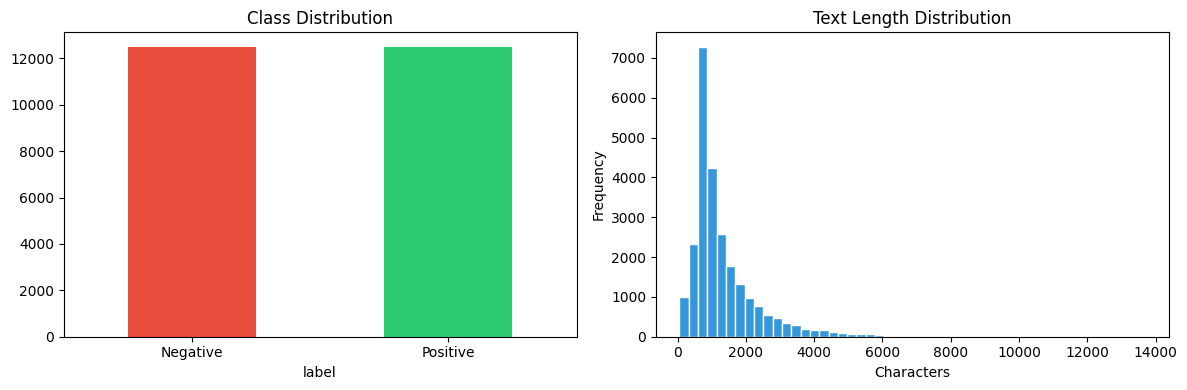

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df["label"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)

# Text length histogram
df["text_length"].plot.hist(ax=axes[1], bins=50, color="#3498db", edgecolor="white")
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

IMDB เป็นชุดข้อมูลที่สะอาดและสมดุล — 25,000 ตัวอย่างต่อ class ไม่มีค่าที่หายไป นี่คือชุดข้อมูลประเภทที่ **ง่ายเกินไป** สำหรับโครงงาน (ความพยายามระดับ 1) เพื่อให้ไม่ธรรมดา คุณต้องทำอะไรบางอย่างเพิ่ม เช่น:

- รวมกับชุดข้อมูลรีวิวอื่นที่ใช้ระบบ labeling ต่างกัน (เช่น 1–5 ดาว → binary)
- กรองเฉพาะ domain แล้วเสริมด้วยรีวิวที่ scrape มาเอง
- ใช้เป็นข้อมูลตั้งต้นเพื่อสร้างตัวอย่างสังเคราะห์ในภาษาอื่น

ประเด็นคือ: **การรู้วิธีโหลดข้อมูลเป็นขั้นตอนแรก การแปลงข้อมูลให้เป็นสิ่งที่มีประโยชน์สำหรับ task ของคุณคือจุดเริ่มต้นที่แท้จริงของงาน**

## 5. Web Scraping — เก็บข้อมูลด้วยตัวเองจากเว็บไซต์

เมื่อชุดข้อมูลที่คุณต้องการไม่มีอยู่ คุณสามารถสร้างมันเองโดยการ scrape เว็บไซต์สาธารณะ Web scraping คือการเขียนโค้ดเพื่อดึงข้อมูลที่มีโครงสร้างจากหน้าเว็บ

ก่อนเขียนโค้ด มาพูดเรื่องจริยธรรมกันก่อน

### จริยธรรมก่อน: robots.txt, Terms of Service, และการขออนุญาต

แค่เพราะเว็บไซต์เปิดให้เข้าถึงได้สาธารณะ ไม่ได้หมายความว่าเจ้าของต้องการให้คุณ scrape ข้อมูลจำนวนมาก ก่อน scrape เว็บไซต์ใดๆ:

1. **ตรวจสอบ `robots.txt`** — เข้า `https://example.com/robots.txt` เพื่อดูว่าเว็บไซต์อนุญาตให้ bot เข้าถึงอะไรบ้าง
2. **อ่าน Terms of Service** — เว็บไซต์บางแห่ง (เช่น social media ส่วนใหญ่) ห้าม scraping อย่างชัดเจน
3. **ถ้าไม่แน่ใจ ให้ถาม** — อีเมลสุภาพถึงเจ้าของเว็บไซต์ช่วยได้มาก
4. **ทำอย่างนุ่มนวล** — เพิ่ม delay ระหว่าง requests เพื่อไม่ให้เซิร์ฟเวอร์รับภาระหนัก

สำหรับบทเรียนนี้ เราใช้ **เว็บไซต์ sandbox สำหรับฝึก scraping** ที่ออกแบบมาให้ถูก scrape: [toscrape.com](https://toscrape.com/) ไม่มีปัญหาจริยธรรม ไม่มีความเสี่ยงที่จะทำอะไรเสียหาย

### Static Web Scraping ด้วย requests + BeautifulSoup

หน้าเว็บ **static** ส่งเนื้อหาทั้งหมดใน HTML response แรก คุณสามารถดึงมาด้วย `requests` และ parse ด้วย `BeautifulSoup`

เราจะ scrape ข้อมูลหนังสือจาก [books.toscrape.com](https://books.toscrape.com/) — เว็บไซต์ sandbox ที่มีหนังสือ 1,000 เล่มใน 50 หน้า

In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
pd.set_option('display.max_colwidth', None)


def get_soup(url):
    """Fetch a URL and return a BeautifulSoup object."""
    response = requests.get(url)
    return BeautifulSoup(response.text, features='html.parser')


# Fetch the first page
base_url = 'https://books.toscrape.com/'
soup = get_soup(base_url)

# Each book is in an <article> tag with class 'product_pod'
books = soup.find_all('article', class_='product_pod')
print(f'Found {len(books)} books on page 1')
print(f'First book title: {books[0].h3.a["title"]}')

Found 20 books on page 1
First book title: A Light in the Attic


In [15]:
# Extract structured data from the first page
def parse_book(article):
    """Extract title, price, rating, and availability from a book article."""
    title = article.h3.a['title']
    price = article.find('p', class_='price_color').text
    
    # Rating is encoded as a CSS class: 'One', 'Two', ..., 'Five'
    rating_class = article.find('p', class_='star-rating')['class'][1]
    rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    rating = rating_map.get(rating_class, 0)
    in_stock = 'In stock' in article.find('p', class_='instock').text
    return {'title': title, 'price': price, 'rating': rating, 'in_stock': in_stock}


# Scrape the first 3 pages
all_books = []
for page_num in range(1, 4):
    url = f'{base_url}catalogue/page-{page_num}.html'
    soup = get_soup(url)
    articles = soup.find_all('article', class_='product_pod')
    for article in articles:
        all_books.append(parse_book(article))
    print(f'Page {page_num}: scraped {len(articles)} books')

df_books = pd.DataFrame(all_books)
print(f'\nTotal books scraped: {len(df_books)}')
df_books.head(10)

Page 1: scraped 20 books
Page 2: scraped 20 books
Page 3: scraped 20 books

Total books scraped: 60


,title,price,rating,in_stock
0,A Light in the Attic,Â£51.77,3,True
1,Tipping the Velvet,Â£53.74,1,True
2,Soumission,Â£50.10,1,True
3,Sharp Objects,Â£47.82,4,True
4,Sapiens: A Brief History of Humankind,Â£54.23,5,True
5,The Requiem Red,Â£22.65,1,True
6,The Dirty Little Secrets of Getting Your Dream Job,Â£33.34,4,True
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",Â£17.93,3,True
8,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,Â£22.60,4,True
9,The Black Maria,Â£52.15,1,True


นั่นคือ pattern หลัก: **ดึง HTML → parse ด้วย BeautifulSoup → ดึงข้อมูล → เก็บใน DataFrame** สำหรับโครงงานจริง คุณจะ scrape ทั้ง 50 หน้าแล้วบันทึกเป็น CSV

สังเกตว่าข้อมูลยังไม่สะอาด — ราคามีสัญลักษณ์สกุลเงิน, rating ถูก encode เป็น CSS classes, ฯลฯ นี่เป็นเรื่องปกติของข้อมูลที่ scrape มา และเป็นงานทำความสะอาดที่ทำให้โครงงานไม่ธรรมดา

### Dynamic Web Scraping ด้วย Selenium

คุณอาจเคยเจอหน้าเว็บที่ components ใช้เวลาสักพักในการ render หรือ render แบบ dynamic เมื่อคุณทำบางอย่าง ตัวอย่างคือ [quotes.toscrape.com/js/](quotes.toscrape.com/js/) มาดูกันว่าจะเกิดอะไรขึ้นถ้าเราใช้วิธีเดิม:

In [16]:
# What happens if we try requests + BeautifulSoup on a JS-rendered page?
js_soup = get_soup('https://quotes.toscrape.com/js/')
js_quotes = js_soup.find_all('div', class_='quote')

print(f'Quotes found with requests + BeautifulSoup: {len(js_quotes)}')
print('The page HTML is mostly empty JavaScript loaders — no content!')

Quotes found with requests + BeautifulSoup: 0
The page HTML is mostly empty JavaScript loaders — no content!


อย่างที่เห็น `requests` คืนค่า quotes เป็นศูนย์ เพราะเนื้อหาของหน้าถูกสร้างโดย JavaScript *หลังจาก* HTML โหลด HTML ดิบเป็นแค่เปลือกว่างที่มี `<script>` tag

[Selenium](https://www.selenium.dev/) แก้ปัญหานี้โดยควบคุม browser จริง (Chrome) ที่ execute JavaScript แล้วให้คุณอ่านหน้าที่ render แล้ว

In [17]:
# Selenium setup differs between Colab and local
if IN_COLAB:
    # google-colab-selenium handles Chrome setup automatically
    import google_colab_selenium as gs
    driver = gs.Chrome()
else:
    # Local: webdriver-manager auto-downloads the correct ChromeDriver
    from selenium import webdriver
    from selenium.webdriver.chrome.service import Service
    from selenium.webdriver.chrome.options import Options
    from webdriver_manager.chrome import ChromeDriverManager
    options = Options()
    options.add_argument('--headless')  # run without opening a window
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options,
    )

from selenium.webdriver.common.by import By
import time

# Navigate to the JS-rendered quotes page
driver.get('https://quotes.toscrape.com/js/')
time.sleep(2)  # wait for JavaScript to render

# Now we can parse the rendered HTML
quotes_elements = driver.find_elements(By.CLASS_NAME, 'quote')
print(f'Found {len(quotes_elements)} quotes on the page')

quotes_data = []
for q in quotes_elements:
    text = q.find_element(By.CLASS_NAME, 'text').text
    author = q.find_element(By.CLASS_NAME, 'author').text
    tags = [t.text for t in q.find_elements(By.CLASS_NAME, 'tag')]
    quotes_data.append({'text': text, 'author': author, 'tags': tags})

driver.quit()

df_quotes = pd.DataFrame(quotes_data)
df_quotes

2026-04-02 23:17:05,615 - INFO - WDM - ====== WebDriver manager ======
2026-04-02 23:17:09,698 - INFO - WDM - Get LATEST chromedriver version for google-chrome
2026-04-02 23:17:09,765 - INFO - WDM - Get LATEST chromedriver version for google-chrome
2026-04-02 23:17:09,813 - INFO - WDM - Driver [/Users/charipol/.wdm/drivers/chromedriver/mac64/146.0.7680.165/chromedriver-mac-arm64/chromedriver] found in cache


Found 10 quotes on the page


,text,author,tags
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"[change, deep-thoughts, thinking, world]"
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"[abilities, choices]"
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"[inspirational, life, live, miracle, miracles]"
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"[aliteracy, books, classic, humor]"
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"[be-yourself, inspirational]"
5,“Try not to become a man of success. Rather become a man of value.”,Albert Einstein,"[adulthood, success, value]"
6,“It is better to be hated for what you are than to be loved for what you are not.”,André Gide,"[life, love]"
7,"“I have not failed. I've just found 10,000 ways that won't work.”",Thomas A. Edison,"[edison, failure, inspirational, paraphrased]"
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,Eleanor Roosevelt,[misattributed-eleanor-roosevelt]
9,"“A day without sunshine is like, you know, night.”",Steve Martin,"[humor, obvious, simile]"


ความแตกต่างหลักจาก static scraping คือ เรา **รอให้ JavaScript ทำงาน** ก่อนที่เนื้อหาจะปรากฏใน DOM `time.sleep(2)` เป็นวิธีง่ายๆ ในงานจริงคุณจะใช้ `WebDriverWait` ของ Selenium เพื่อการรอที่แม่นยำกว่า

Selenium ช้าและหนักกว่า `requests + BeautifulSou`p ดังนั้นใช้เฉพาะเมื่อเนื้อหาถูก render ด้วย JavaScript จริงๆ วิธีทดสอบคือถ้าคุณ `view-source:` บนหน้าเว็บแล้วข้อมูลไม่อยู่ใน HTML ดิบ คุณต้องใช้ Selenium (หรือเครื่องมือคล้ายกัน)

## 6. สร้างข้อมูลสังเคราะห์

บางครั้งคุณหาหรือ scrape ข้อมูลได้ไม่พอ ในกรณีนั้น คุณสามารถสร้างมันขึ้นมาเองได้ นี่คือข้อสรุปจากงานวิจัย Phi-1 ที่ได้กล่าวถึงไปในข้างต้น ข้อมูลสังเคราะห์คุณภาพสูงมีประสิทธิภาพอย่างน่าทึ่ง

เราจะยกตัวอย่างการสร้างข้อมูลสังเคราะห์ 3 ประเภทคือ text, images, และ tabular data; จุดร่วมที่สำคัญคือ **ข้อมูลสังเคราะห์เป็นจุดเริ่มต้น ไม่ใช่ผลิตภัณฑ์สำเร็จรูป** คุณต้องตรวจสอบและคัดสรร output เสมอ

**ข้อควรระวังอันดับหนึ่งสำหรับข้อมูลสังเคราะห์** คือ ห้ามใช้ตัวอย่างสังเคราะห์เหล่านี้เป็น test set เด็ดขาดเพราะจะทำให้ผลการประเมินดูดีเกินจริง หรือแม้แต่ใน validation set ก็ควรใช้อย่างระมัดระวัง; ใช้แค่ใน training set จะดีที่สุด

### สร้างข้อมูลข้อความด้วย DSPy + Qwen3-0.6B

ในบทที่ 1 คุณใช้ DSPy สร้างระบบ reading comprehension ตอนนี้เราจะใช้เครื่องมือเดียวกันเพื่อ **สร้างข้อมูลเทรนที่มี label**

แนวคิด: กำหนด DSPy signature ที่รับหัวข้อแล้วสร้างตัวอย่างที่มี label (เช่น product review พร้อม sentiment label) จากนั้นรันหลายครั้งเพื่อสร้างชุดข้อมูล สุดท้าย ตรวจสอบผลลัพธ์แล้วทิ้งตัวที่ไม่ดี

มาสร้าง product reviews ที่มี sentiment label กัน

In [18]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
import torch, re

model_name = 'Qwen/Qwen3-0.6B'
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
)

print(f'Loading {model_name}...')
tokenizer = AutoTokenizer.from_pretrained(model_name)
hf_model = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=quantization_config, device_map='auto',
)
print('Model loaded!')

Loading Qwen/Qwen3-0.6B...


2026-04-02 23:20:26,504 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-02 23:20:26,515 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/config.json "HTTP/1.1 200 OK"
2026-04-02 23:20:26,695 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-02 23:20:26,706 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/tokenizer_config.json "HTTP/1.1 200 OK"
2026-04-02 23:20:26,896 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen3-0.6B/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-02 23:20:27,068 - INFO - httpx - HTTP Request: GET https://huggingf

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
2026-04-02 23:20:35,316 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-02 23:20:35,332 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/generation_config.json "HTTP/1.1 200 OK"


Model loaded!


In [19]:
import dspy

def strip_thinking(text):
    """Remove Qwen3's <think>...</think> reasoning block from output."""
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    text = re.sub(r'<think>.*', '', text, flags=re.DOTALL)
    return text.strip()


class LocalQwen(dspy.BaseLM):
    """Minimal wrapper: reuse our already-loaded HF model for DSPy."""
    def __init__(self, hf_model, hf_tokenizer, **kwargs):
        super().__init__(model='local-qwen3-0.6b', **kwargs)
        self.hf_model = hf_model
        self.hf_tokenizer = hf_tokenizer

    def forward(self, prompt=None, messages=None, **kwargs):
        if messages is None:
            messages = [{'role': 'user', 'content': prompt}]
        text = self.hf_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
        )
        inputs = self.hf_tokenizer(text, return_tensors='pt').to(self.hf_model.device)
        input_len = inputs['input_ids'].shape[1]
        max_tok = kwargs.get('max_tokens') or self.kwargs.get('max_tokens', 256)
        with torch.no_grad():
            out = self.hf_model.generate(**inputs, max_new_tokens=max_tok, do_sample=False)
        answer = self.hf_tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()
        answer = strip_thinking(answer)
        import time
        from openai.types.chat import ChatCompletion, ChatCompletionMessage
        from openai.types.chat.chat_completion import Choice
        from openai.types import CompletionUsage
        n_gen = len(out[0]) - input_len
        return ChatCompletion(
            id=f'local-{int(time.time())}', created=int(time.time()),
            model='local-qwen3-0.6b', object='chat.completion',
            choices=[Choice(finish_reason='stop', index=0,
                            message=ChatCompletionMessage(role='assistant', content=answer))],
            usage=CompletionUsage(prompt_tokens=input_len, completion_tokens=n_gen,
                                  total_tokens=input_len + n_gen),
        )


lm = LocalQwen(hf_model, tokenizer, max_tokens=256)
dspy.configure(lm=lm)
print('DSPy configured!')

DSPy configured!


In [20]:
# Define a signature for generating labeled reviews
class GenerateReview(dspy.Signature):
    """Generate a realistic product review for the given product category with the specified sentiment."""
    product_category = dspy.InputField(desc='the product category, e.g. headphones, laptop, running shoes')
    sentiment = dspy.InputField(desc='positive or negative')
    review_text = dspy.OutputField(desc='a realistic 2-3 sentence product review')
    sentiment_label = dspy.OutputField(desc='positive or negative, must match the requested sentiment')


generator = dspy.Predict(GenerateReview)

# Generate a batch of reviews
categories = ['headphones', 'laptop', 'running shoes', 'backpack', 'water bottle']
sentiments = ['positive', 'negative']

synthetic_reviews = []
for cat in categories:
    for sent in sentiments:
        result = generator(product_category=cat, sentiment=sent)
        synthetic_reviews.append({
            'category': cat,
            'requested_sentiment': sent,
            'review_text': result.review_text,
            'generated_label': result.sentiment_label,
        })

df_synthetic = pd.DataFrame(synthetic_reviews)
print(f'Generated {len(df_synthetic)} synthetic reviews')
df_synthetic

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Generated 10 synthetic reviews


,category,requested_sentiment,review_text,generated_label
0,headphones,positive,I have a great headphones experience! The sound is clear and the design is very nice. The headphones are great for listening to music and movies.,{positive}
1,headphones,negative,"I don't think I can use headphones for a review. They are usually used for audio playback, not for running. I would say the product is not as good as expected.",negative
2,laptop,positive,I have a great laptop that is well-built and has a great display. It has a powerful processor and a decent battery life. I would recommend this laptop for its performance and design.,positive
3,laptop,negative,"The laptop is a bit heavy and has a decent price, but the overall experience is not very enjoyable. It's a bit of a struggle to get the right balance between quality and cost.",negative
4,running shoes,positive,I bought a pair of running shoes and they fit perfectly. The material is comfortable and the design is great for long runs. I'm really happy with this purchase!,positive
5,running shoes,negative,"I don't think I've ever seen a running shoe that I really like. The design is a bit outdated, and the material isn't very comfortable. I'm not sure if this is a good purchase.",negative
6,backpack,positive,I bought a backpack for my daily needs and it's a great addition to my travel experience. The design is practical and the materials are comfortable. It's a positive review.,positive
7,backpack,negative,"I don't think I can really review a backpack, but I can say it's a bit heavy and I don't think it's very useful for me. I think I need a lighter backpack.",negative
8,water bottle,positive,"A water bottle is a convenient and practical item that provides a long-lasting source of energy and is perfect for daily use. It is lightweight, durable, and designed to keep you energized throughout the day.",positive
9,water bottle,negative,"I don't think I can drink water, it's too heavy. The bottle is pretty big, and I can't hold it. I think it's a bit too heavy for me.",negative


### ตรวจสอบคุณภาพข้อมูลสังเคราะห์

สิ่งที่สำคัญที่สุดสำหรับการสร้างข้อมูลสังเคราะห์คือ **ข้อมูลที่สร้างขึ้นสมเหตุสมผลจริงหรือเปล่า?** มาตรวจสอบว่าโมเดลทำตามคำสั่ง sentiment ของเราหรือไม่

In [21]:
# Check: did the model generate the sentiment we asked for?
df_synthetic['label_match'] = (
    df_synthetic['requested_sentiment'].str.lower() ==
    df_synthetic['generated_label'].str.lower()
)

match_rate = df_synthetic['label_match'].mean()
print(f'Label match rate: {match_rate:.0%}')
print()

# Show any mismatches
mismatches = df_synthetic[~df_synthetic['label_match']]
if len(mismatches) > 0:
    print(f'Found {len(mismatches)} mismatches:')
    for _, row in mismatches.iterrows():
        print(f'  Requested: {row["requested_sentiment"]}, Got: {row["generated_label"]}')
        print(f'  Review: {row["review_text"][:100]}...')
        print()
else:
    print('All labels match! But you should still read a few reviews manually.')
    print('Small models can generate plausible-sounding text with subtle errors.')

Label match rate: 90%

Found 1 mismatches:
  Requested: positive, Got: {positive}
  Review: I have a great headphones experience! The sound is clear and the design is very nice. The headphones...



ในโลกปัจจุบัน การสร้างข้อมูลสังเคราะห์เป็นส่วนที่ง่าย การตรวจสอบต่างหากที่เป็นส่วนที่ยาก อัตราการตรงกันของ label 100% ไม่ได้หมายความว่ารีวิวดี คุณยังต้องอ่านและตรวจสอบ:

- ภาษาที่ซ้ำซากหรือเป็นแม่แบบ
- ข้อผิดพลาดเชิงข้อเท็จจริง (เช่น รีวิวชมแบตเตอรี่ของขวดน้ำ)
- สำนวนที่ไม่เป็นธรรมชาติ
- Labels ที่ตรงทางเทคนิคแต่รีวิวคลุมเครือ

สำหรับโครงงาน คุณจะสร้างตัวอย่างหลายร้อยตัวอย่าง ตรวจสอบด้วยตาสัก 10–20% ทิ้งตัวที่ไม่ดี แล้วอาจสร้างใหม่ด้วย prompts ที่ปรับปรุงแล้ว นี่คือความพยายาม **ระดับ 4** อย่าให้ใครมาเรียกคุณว่า AI Slop King ได้

### สร้างรูปภาพด้วย Tiny Stable Diffusion

เช่นเดียวกับที่ LLMs สร้างข้อมูลข้อความได้ diffusion models ก็สร้างข้อมูลรูปภาพได้ [Segmind Tiny-SD](https://huggingface.co/segmind/tiny-sd) เป็น Stable Diffusion เวอร์ชัน knowledge-distilled — parameters เล็กกว่าปกติกว่า 55% รันบน hardware ทั่วไปได้ และใช้ `diffusers` pipeline มาตรฐาน

คุณภาพอาจจะไม่ได้สวยมาก (เป็นโมเดลเล็ก) ซึ่งมีประโยชน์ในเชิงการสอน: คุณจะเห็นว่ารูปภาพสังเคราะห์ก็ต้องการการคัดสรรเช่นกัน

In [22]:
from diffusers import DiffusionPipeline

# Load Tiny Stable Diffusion
pipe = DiffusionPipeline.from_pretrained(
    'segmind/tiny-sd',
    torch_dtype=torch.float16 if DEVICE.type != 'cpu' else torch.float32,
)
pipe = pipe.to(DEVICE)
print('Tiny-SD loaded!')

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/charipol/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Tiny-SD loaded!


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

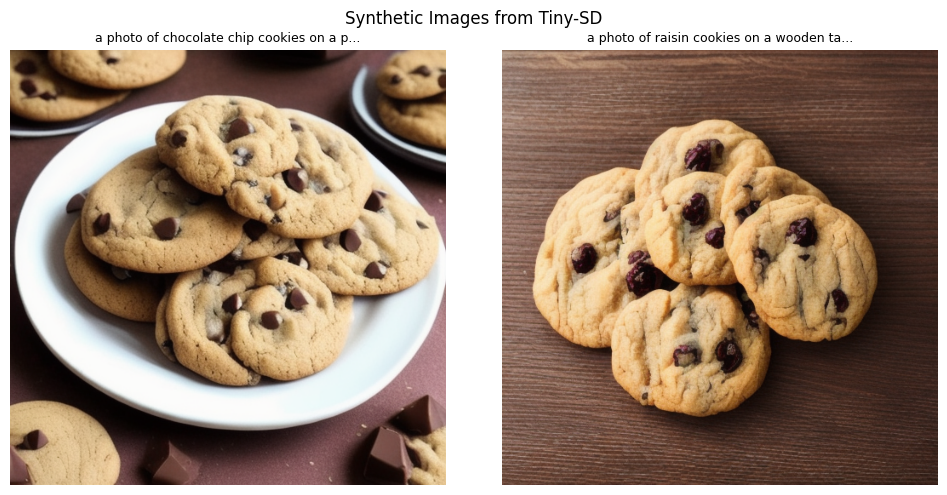

In [23]:
# Generate a few images for our cookie classifier
prompts = [
    'a photo of chocolate chip cookies on a plate, food photography',
    'a photo of raisin cookies on a wooden table, food photography',
]

fig, axes = plt.subplots(1, len(prompts), figsize=(10, 5))
for i, prompt in enumerate(prompts):
    image = pipe(prompt, num_inference_steps=25).images[0]
    axes[i].imshow(image)
    axes[i].set_title(prompt[:40] + '...', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Synthetic Images from Tiny-SD', fontsize=12)
plt.tight_layout()
plt.show()

รูปภาพสังเคราะห์มีประโยชน์มากที่สุดสำหรับ:

- **เสริม class ที่หายาก** — ถ้าคุณมีรูป 500 รูปของ class A แต่มีแค่ 20 รูปของ class B ให้สร้างเพิ่มสำหรับ B
- **เริ่มต้นชุดข้อมูล** — สร้างรูปเริ่มต้น แล้วแทนที่ด้วยรูปจริงเมื่อเก็บได้มากขึ้น
- **Data augmentation** — สร้างรูปที่หลากหลายจากรูปที่มีอยู่

มีประโยชน์น้อยกว่าเมื่อ task ต้องการความสมจริงระดับภาพถ่ายหรือความแม่นยำเฉพาะ domain (เช่น medical imaging)

### สร้างข้อมูลตาราง

คุณยังสามารถใช้ LLMs สร้างข้อมูลตารางได้ วิธีการเหมือนกับการสร้างข้อความ: อธิบาย schema ขอให้โมเดลสร้าง rows แล้วตรวจสอบ output

นี่คือตัวอย่างเร็วๆ โดยใช้ DSPy + Qwen3-0.6B เดิม:

In [24]:
class GenerateCustomerRow(dspy.Signature):
    """Generate a single realistic row of customer data matching the given schema."""
    schema_description = dspy.InputField(
        desc='description of the columns and their types/ranges'
    )
    customer_segment = dspy.InputField(
        desc='the customer segment to generate for, e.g. young professional, retiree'
    )
    age = dspy.OutputField(desc='integer between 18 and 80')
    annual_income = dspy.OutputField(desc='integer in USD, realistic for the segment')
    monthly_spend = dspy.OutputField(desc='integer in USD, realistic for the segment')
    loyalty_score = dspy.OutputField(desc='float between 0.0 and 1.0')


row_generator = dspy.Predict(GenerateCustomerRow)

schema_desc = (
    'Customer data with columns: age (18-80), annual_income (USD), '
    'monthly_spend (USD), loyalty_score (0.0-1.0)'
)

segments = ['young professional', 'college student', 'retiree', 'working parent']
rows = []
for seg in segments:
    result = row_generator(schema_description=schema_desc, customer_segment=seg)
    rows.append({
        'segment': seg,
        'age': result.age,
        'annual_income': result.annual_income,
        'monthly_spend': result.monthly_spend,
        'loyalty_score': result.loyalty_score,
    })

df_tabular = pd.DataFrame(rows)
print('Synthetic tabular data:')
df_tabular

/Users/charipol/Work/curriculum/.venv/lib/python3.11/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Synthetic tabular data:


,segment,age,annual_income,monthly_spend,loyalty_score
0,young professional,18,15000,200,0.8
1,college student,18,1500,200,0.8
2,retiree,35,5000,200,0.8
3,working parent,35,5000,200,0.8


นี่เป็นการสาธิตอย่างง่าย สำหรับการสร้างข้อมูลตารางระดับ production ด้วย LLMs ลองดู [AdaRec](https://github.com/amazon-science/AdaRec) — framework ที่แปลงข้อมูลลูกค้าแบบตารางเป็น narrative profiles โดยใช้ LLMs แล้วใช้ few-shot learning ทำนาย counterfactual outcomes แสดงให้เห็นว่า LLMs สามารถเชื่อมช่องว่างระหว่างข้อมูลโครงสร้างและการให้เหตุผลด้วยภาษาธรรมชาติ

หลักการทั่วไปใช้ได้กับทุก modality: **สร้าง → ตรวจสอบ → คัดสรร → ยืนยัน** ข้อมูลสังเคราะห์เป็นเครื่องมือ ไม่ใช่ทางลัด

## 7. รายการตรวจสอบคุณภาพข้อมูล

ก่อนเริ่มเทรนโมเดล ให้ตรวจสอบตามรายการนี้ว่าสอดคล้องกับเกณฑ์การให้คะแนนโครงงาน AI Builders หรือไม่ — ถ้าคุณทำเครื่องหมายไม่ครบทุกข้อ ข้อมูลของคุณยังไม่พร้อม

### การทดสอบความพยายามที่ไม่ธรรมดา

- [ ] คุณอธิบายได้ไหมว่าข้อมูลมาจากไหนและทำไมถึงเหมาะกับ task ของคุณ?
- [ ] คุณทำขั้นตอนเตรียมข้อมูลที่ไม่ธรรมดาอย่างน้อยหนึ่งขั้นตอนหรือไม่? (รวมแหล่งข้อมูล, scraping, ติด label, ทำความสะอาด, augmenting, สร้างข้อมูล ฯลฯ)
- [ ] คุณแสดงตัวอย่างก่อน/หลังของการเตรียมข้อมูลได้ไหม?

### คุณภาพ Label

- [ ] คุณตรวจสอบตัวอย่าง labels แบบสุ่มด้วยตา (อย่างน้อย 20–50 ตัวอย่าง) หรือไม่?
- [ ] Labels สม่ำเสมอไหม? (คนสองคนจะให้ label เดียวกันไหม?)
- [ ] ถ้า labels ถูกสร้างโดยโมเดล คุณวัดและรายงานอัตราข้อผิดพลาดหรือไม่?

### คุณภาพ Input

- [ ] คุณตรวจสอบข้อมูลซ้ำหรือไม่?
- [ ] คุณตรวจสอบ inputs ที่เสียหายหรือว่างเปล่า (รูปภาพเสีย, string ว่าง, ค่า NaN) หรือไม่?
- [ ] คุณตรวจสอบปัญหา encoding (mojibake, character set ผิด) หรือไม่?
- [ ] คุณดู distribution ของ input features (ความยาว, ช่วงค่า, ค่าเฉลี่ย, มัธยฐาน, เปอร์เซนไทล์ ฯลฯ) หรือไม่?

### Train / Validation / Test Splits

- [ ] splits ของคุณเป็นแบบ random หรือ stratified (รักษาสมดุล class)?
- [ ] ไม่มี data leakage ระหว่าง splits? (ไม่มีตัวอย่างซ้ำหรือเกือบซ้ำข้าม splits)
- [ ] ถ้าข้อมูลมีมิติเวลา คุณแบ่งตามเวลาก่อน-หลัง (ไม่ใช่แบบสุ่ม) หรือไม่?
- [ ] test set เป็นตัวแทนของ distribution ในโลกจริงที่คุณสนใจหรือไม่?

## 8. แผนข้อมูลของคุณ

กรอกแบบฟอร์มด้านล่างเพื่อวางแผนข้อมูลสำหรับโครงงาน AI Builders ของคุณ จะช่วยให้คุณคิดเรื่องกลยุทธ์ข้อมูลก่อนเริ่มสร้าง และให้ mentors มีสิ่งที่จับต้องได้ในการรีวิว

In [ ]:
# ============================================================
# YOUR DATA PLAN — fill this in for your project
# ============================================================

# 1. What is your task?
#    Example: 'Classify Thai street food images into 10 categories'
MY_TASK = ''

# 2. Where will your data come from? (be specific — URLs, APIs, dataset names)
#    Example: 'HuggingFace food-101 dataset + 200 images I photograph myself'
MY_DATA_SOURCES = ''

# 3. What makes your data collection non-trivial?
#    What work do YOU have to do beyond downloading?
#    Example: 'food-101 does not have Thai food categories, so I need to
#     re-label 500 images and supplement with my own photos'
MY_DATA_EFFORT = ''

# 4. Estimated dataset size
#    Example: '1,200 images (800 train / 200 val / 200 test)'
MY_DATASET_SIZE = ''

# 5. How will you verify data quality?
#    Example: 'Manual inspection of 50 random samples per class,
#     check for duplicates with image hashing'
MY_QUALITY_PLAN = ''

# 6. Data effort level (circle one): 1 / 2 / 3 / 4
#    Refer to the Data Effort Spectrum in Section 1.
#    Remember: Level 1 is NOT ENOUGH for your project.
MY_EFFORT_LEVEL = 0

# Print your plan
print('=== YOUR DATA PLAN ===')
print(f'Task:           {MY_TASK}')
print(f'Data sources:   {MY_DATA_SOURCES}')
print(f'Non-trivial:    {MY_DATA_EFFORT}')
print(f'Dataset size:   {MY_DATASET_SIZE}')
print(f'Quality plan:   {MY_QUALITY_PLAN}')
print(f'Effort level:   {MY_EFFORT_LEVEL}')
if MY_EFFORT_LEVEL < 2:
    print('\n⚠️  Your effort level needs to be at least 2!')

## ต่อไป

ตอนนี้คุณมีเครื่องมือในการหา เก็บ สร้าง และตรวจสอบข้อมูลสำหรับโครงงานแล้ว ในบทที่ 3 เราจะ a) เรียนรู้วิธีประเมินโมเดลอย่างเข้มงวด และ b) ลงลึกใน training loop โดยสร้าง stochastic gradient descent ตั้งแต่ต้น เพื่อให้คุณเข้าใจว่าโมเดลเรียนรู้จากข้อมูลที่คุณเตรียมไว้อย่างไร

ก่อนสัปดาห์หน้า:

1. กรอกแผนข้อมูลด้านบน
2. เริ่มเก็บหรือระบุข้อมูลสำหรับโครงงาน
3. รัน Data Quality Checklist กับข้อมูลที่มีอยู่